In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

current_dir = Path.cwd()

if (current_dir / "data").exists():
    project_root = current_dir
elif (current_dir.parent / "data").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError(
        f"Cannot find project root. Current directory: {current_dir}"
    )

data_path = (
    project_root
    / "data"
    / "processed"
    / "dst_reviews_english_text.csv"
)

figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

text_df = pd.read_csv(data_path)

print("Data shape:", text_df.shape)
print("Data path:", data_path)

text_df.head()

Data shape: (4511, 29)
Data path: /Users/zhouzhou/Desktop/dst-review-analysis/data/processed/dst_reviews_english_text.csv


,recommendation_id,language,review,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,timestamp_created,timestamp_updated,playtime_forever_minutes,playtime_at_review_minutes,num_games_owned,author_num_reviews,created_at,updated_at,playtime_forever_hours,playtime_at_review_hours,review_date,review_year,review_month,review_length_chars,review_word_count,review_length_category,detected_language,contains_non_latin_script
0,232146949,english,Klei Entertainment was whippin' up actual shi in a kettle. Boiling shi in a kettle. He was whippin' up actual poo in...,False,0,0,0.500000,0,False,False,False,1785965086,1785965086,265.0,265.0,110,29,2026-08-05 21:24:46+00:00,2026-08-05 21:24:46+00:00,4.416667,4.416667,2026-08-05,2026,2026-08,162,31,Medium,en,False
1,232134193,english,So much content! When you get over the starting hurdle of surviving its so fun to explore and find out what everythi...,True,0,0,0.500000,0,False,False,False,1785952590,1785952590,15951.0,15621.0,0,1,2026-08-05 17:56:30+00:00,2026-08-05 17:56:30+00:00,265.850000,260.350000,2026-08-05,2026,2026-08,121,23,Medium,en,False
2,232131462,english,Pretty good game is a bit hard for new players so its best if youre starting out to look some stuff up or have a fri...,True,0,0,0.500000,0,False,True,False,1785949854,1785949854,814.0,515.0,9,2,2026-08-05 17:10:54+00:00,2026-08-05 17:10:54+00:00,13.566667,8.583333,2026-08-05,2026,2026-08,133,28,Medium,en,False
3,232114765,english,awesome game!,True,0,0,0.500000,0,True,False,False,1785934292,1785934292,1793.0,1564.0,268,52,2026-08-05 12:51:32+00:00,2026-08-05 12:51:32+00:00,29.883333,26.066667,2026-08-05,2026,2026-08,13,2,Very short,unknown_short,False
4,232113302,english,The game is such an actual slog to play through that I genuinely do not understand how anyone could find it fun. \n\...,False,0,0,0.454545,0,True,False,False,1785932719,1785932719,164.0,164.0,610,12,2026-08-05 12:25:19+00:00,2026-08-05 12:25:19+00:00,2.733333,2.733333,2026-08-05,2026,2026-08,483,87,Long,en,False


In [2]:
print("Original type:", text_df["voted_up"].dtype)
print("Original values:", text_df["voted_up"].unique())

Original type: bool
Original values: [False  True]


In [3]:
if not pd.api.types.is_bool_dtype(text_df["voted_up"]):
    text_df["voted_up"] = (
        text_df["voted_up"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

text_df = text_df.dropna(
    subset=["review", "voted_up"]
).copy()

text_df["review"] = (
    text_df["review"]
    .astype(str)
    .str.strip()
)

text_df = text_df[
    text_df["review"].ne("")
].copy()

print("Clean text shape:", text_df.shape)
print("voted_up type:", text_df["voted_up"].dtype)
print(text_df["voted_up"].value_counts())

Clean text shape: (4511, 29)
voted_up type: bool
voted_up
True     4093
False     418
Name: count, dtype: int64


In [4]:
positive_texts = text_df.loc[
    text_df["voted_up"].eq(True),
    "review",
]

negative_texts = text_df.loc[
    text_df["voted_up"].eq(False),
    "review",
]

print("Positive text reviews:", len(positive_texts))
print("Negative text reviews:", len(negative_texts))

print(
    "Positive rate:",
    f"{len(positive_texts) / len(text_df) * 100:.2f}%",
)

Positive text reviews: 4093
Negative text reviews: 418
Positive rate: 90.73%


In [5]:
def get_top_terms(
    texts,
    top_n=20,
    ngram_range=(1, 1),
    min_df=5,
):
    """Return the most frequent terms in a collection of reviews."""

    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
        ngram_range=ngram_range,
        min_df=min_df,
    )

    term_matrix = vectorizer.fit_transform(texts)

    term_counts = term_matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    result = pd.DataFrame(
        {
            "term": terms,
            "count": term_counts,
        }
    )

    result = (
        result.sort_values(
            "count",
            ascending=False,
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result

In [6]:
positive_top_words = get_top_terms(
    positive_texts,
    top_n=20,
    ngram_range=(1, 1),
    min_df=5,
)

negative_top_words = get_top_terms(
    negative_texts,
    top_n=20,
    ngram_range=(1, 1),
    min_df=5,
)

print("Top words in recommended reviews")
display(positive_top_words)

print("Top words in not-recommended reviews")
display(negative_top_words)

Top words in recommended reviews


,term,count
0,game,2567
1,fun,904
2,good,604
3,friends,591
4,play,582
5,starve,454
6,like,447
7,survival,427
8,it's,380
9,love,376


Top words in not-recommended reviews


,term,count
0,game,513
1,just,157
2,like,118
3,play,100
4,time,68
5,don't,63
6,it's,61
7,fun,60
8,survival,49
9,games,47


In [7]:
positive_top_words.to_csv(
    tables_dir / "positive_top_words_initial.csv",
    index=False,
)

negative_top_words.to_csv(
    tables_dir / "negative_top_words_initial.csv",
    index=False,
)

print("Word-frequency tables saved to:", tables_dir)

Word-frequency tables saved to: /Users/zhouzhou/Desktop/dst-review-analysis/outputs/tables


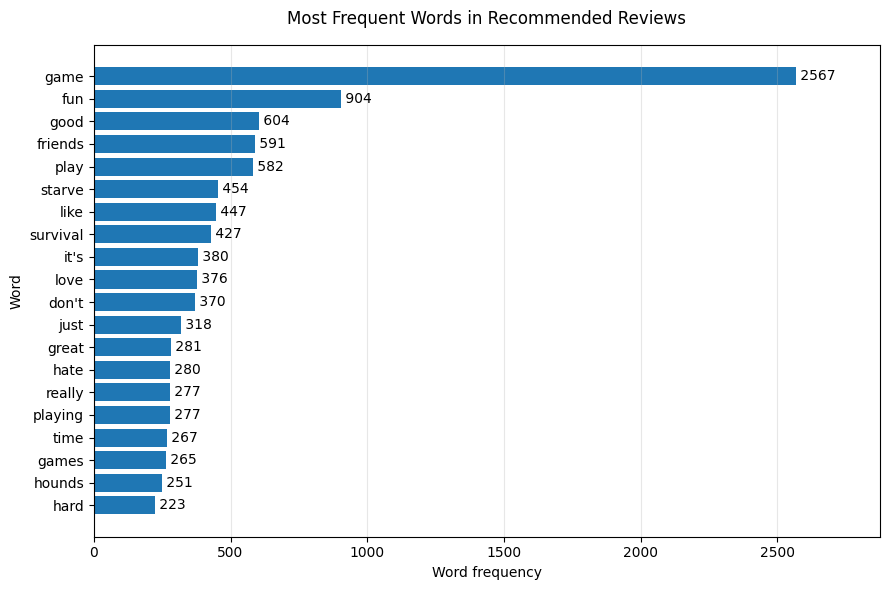

In [8]:
positive_plot_data = (
    positive_top_words
    .sort_values("count")
)

figure, axis = plt.subplots(figsize=(9, 6))

axis.barh(
    positive_plot_data["term"],
    positive_plot_data["count"],
)

axis.set_title(
    "Most Frequent Words in Recommended Reviews",
    pad=15,
)
axis.set_xlabel("Word frequency")
axis.set_ylabel("Word")
axis.grid(
    axis="x",
    alpha=0.3,
)

maximum_count = positive_plot_data["count"].max()

axis.set_xlim(
    0,
    maximum_count * 1.12,
)

for index, value in enumerate(
    positive_plot_data["count"]
):
    axis.text(
        value,
        index,
        f" {int(value)}",
        va="center",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "08_positive_top_words_initial.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

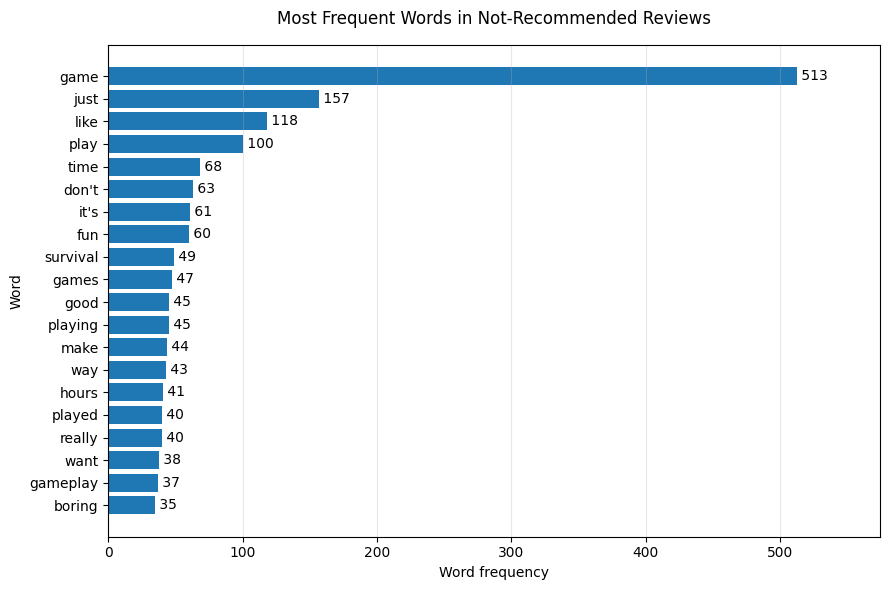

In [9]:
negative_plot_data = (
    negative_top_words
    .sort_values("count")
)

figure, axis = plt.subplots(figsize=(9, 6))

axis.barh(
    negative_plot_data["term"],
    negative_plot_data["count"],
)

axis.set_title(
    "Most Frequent Words in Not-Recommended Reviews",
    pad=15,
)
axis.set_xlabel("Word frequency")
axis.set_ylabel("Word")
axis.grid(
    axis="x",
    alpha=0.3,
)

maximum_count = negative_plot_data["count"].max()

axis.set_xlim(
    0,
    maximum_count * 1.12,
)

for index, value in enumerate(
    negative_plot_data["count"]
):
    axis.text(
        value,
        index,
        f" {int(value)}",
        va="center",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "09_negative_top_words_initial.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [10]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

base_stop_words = set(ENGLISH_STOP_WORDS)

# 保留否定词，避免丢失重要情感信息
base_stop_words -= {
    "not",
    "no",
    "nor",
}

domain_stop_words = {
    # 游戏名称和简称
    "game",
    "games",
    "don't",
    "starve",
    "together",
    "dst",

    # 过于通用的游戏评论词
    "play",
    "played",
    "playing",

    # 缺少具体含义的常见表达
    "it's",
    "just",
    "like",
    "really",
    "thing",
    "things",
}

custom_stop_words = sorted(
    base_stop_words | domain_stop_words
)

print("Number of stop words:", len(custom_stop_words))

Number of stop words: 329


In [11]:
def compare_term_review_rates(
    data,
    ngram_range=(1, 1),
    min_df=5,
):
    """
    Compare the percentage of positive and negative reviews
    containing each term.
    """

    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=custom_stop_words,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
        ngram_range=ngram_range,
        min_df=min_df,
        binary=True,
    )

    term_matrix = vectorizer.fit_transform(
        data["review"]
    )

    terms = vectorizer.get_feature_names_out()

    positive_mask = (
        data["voted_up"]
        .eq(True)
        .to_numpy()
    )

    negative_mask = (
        data["voted_up"]
        .eq(False)
        .to_numpy()
    )

    positive_review_rate = (
        term_matrix[positive_mask]
        .mean(axis=0)
        .A1
        * 100
    )

    negative_review_rate = (
        term_matrix[negative_mask]
        .mean(axis=0)
        .A1
        * 100
    )

    comparison = pd.DataFrame(
        {
            "term": terms,
            "positive_review_rate": positive_review_rate,
            "negative_review_rate": negative_review_rate,
        }
    )

    comparison["difference_pp"] = (
        comparison["positive_review_rate"]
        - comparison["negative_review_rate"]
    )

    return comparison

In [12]:
unigram_comparison = compare_term_review_rates(
    text_df,
    ngram_range=(1, 1),
    min_df=5,
)

print("Terms analysed:", len(unigram_comparison))

Terms analysed: 1437


In [13]:
positive_distinctive_words = (
    unigram_comparison
    .sort_values(
        "difference_pp",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

positive_distinctive_words.round(2)

,term,positive_review_rate,negative_review_rate,difference_pp
0,fun,19.33,9.57,9.76
1,friends,13.24,5.98,7.26
2,love,8.43,2.15,6.28
3,good,13.71,8.37,5.33
4,best,5.11,1.44,3.67
5,great,6.55,3.35,3.20
6,amazing,2.91,0.24,2.67
7,nice,2.93,0.96,1.97
8,cool,2.79,1.20,1.59
9,peak,2.05,0.48,1.57


In [14]:
negative_distinctive_words = (
    unigram_comparison
    .sort_values(
        "difference_pp",
        ascending=True,
    )
    .head(20)
    .reset_index(drop=True)
)

negative_distinctive_words.round(2)

,term,positive_review_rate,negative_review_rate,difference_pp
0,not,6.69,28.23,-21.54
1,no,3.18,16.51,-13.33
2,time,5.42,13.40,-7.97
3,boring,0.46,7.66,-7.19
4,bad,0.83,7.42,-6.59
5,make,2.57,8.13,-5.57
6,way,2.13,7.66,-5.53
7,gameplay,2.25,6.46,-4.21
8,want,1.83,5.98,-4.15
9,didn't,0.95,5.02,-4.07


In [15]:
bigram_comparison = compare_term_review_rates(
    text_df,
    ngram_range=(2, 2),
    min_df=3,
)

In [16]:
positive_distinctive_bigrams = (
    bigram_comparison
    .sort_values(
        "difference_pp",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

positive_distinctive_bigrams.round(2)

,term,positive_review_rate,negative_review_rate,difference_pp
0,fun friends,3.08,0.72,2.36
1,best survival,1.25,0.00,1.25
2,learning curve,1.17,0.48,0.69
3,highly recommend,0.66,0.00,0.66
4,great friends,0.64,0.00,0.64
5,super fun,0.61,0.00,0.61
6,pretty fun,0.61,0.00,0.61
7,hard fun,0.54,0.00,0.54
8,lot fun,0.54,0.00,0.54
9,better friends,0.51,0.00,0.51


In [17]:
negative_distinctive_bigrams = (
    bigram_comparison
    .sort_values(
        "difference_pp",
        ascending=True,
    )
    .head(20)
    .reset_index(drop=True)
)

negative_distinctive_bigrams.round(2)

,term,positive_review_rate,negative_review_rate,difference_pp
0,not worth,0.00,1.91,-1.91
1,not recommend,0.07,1.67,-1.60
2,not fun,0.10,1.67,-1.58
3,new player,0.22,1.67,-1.45
4,no tutorial,0.07,1.44,-1.36
5,there's no,0.12,1.44,-1.31
6,not buy,0.00,1.20,-1.20
7,waste time,0.05,1.20,-1.15
8,does not,0.29,1.44,-1.14
9,no reason,0.07,1.20,-1.12


In [18]:
positive_distinctive_words.to_csv(
    tables_dir / "positive_distinctive_words.csv",
    index=False,
)

negative_distinctive_words.to_csv(
    tables_dir / "negative_distinctive_words.csv",
    index=False,
)

positive_distinctive_bigrams.to_csv(
    tables_dir / "positive_distinctive_bigrams.csv",
    index=False,
)

negative_distinctive_bigrams.to_csv(
    tables_dir / "negative_distinctive_bigrams.csv",
    index=False,
)

print("Distinctive term tables saved.")

Distinctive term tables saved.


In [19]:
print("Positive distinctive words")
display(positive_distinctive_words.round(2))

print("Negative distinctive words")
display(negative_distinctive_words.round(2))

print("Positive distinctive bigrams")
display(positive_distinctive_bigrams.round(2))

print("Negative distinctive bigrams")
display(negative_distinctive_bigrams.round(2))

Positive distinctive words


,term,positive_review_rate,negative_review_rate,difference_pp
0,fun,19.33,9.57,9.76
1,friends,13.24,5.98,7.26
2,love,8.43,2.15,6.28
3,good,13.71,8.37,5.33
4,best,5.11,1.44,3.67
5,great,6.55,3.35,3.20
6,amazing,2.91,0.24,2.67
7,nice,2.93,0.96,1.97
8,cool,2.79,1.20,1.59
9,peak,2.05,0.48,1.57


Negative distinctive words


,term,positive_review_rate,negative_review_rate,difference_pp
0,not,6.69,28.23,-21.54
1,no,3.18,16.51,-13.33
2,time,5.42,13.40,-7.97
3,boring,0.46,7.66,-7.19
4,bad,0.83,7.42,-6.59
5,make,2.57,8.13,-5.57
6,way,2.13,7.66,-5.53
7,gameplay,2.25,6.46,-4.21
8,want,1.83,5.98,-4.15
9,didn't,0.95,5.02,-4.07


Positive distinctive bigrams


,term,positive_review_rate,negative_review_rate,difference_pp
0,fun friends,3.08,0.72,2.36
1,best survival,1.25,0.00,1.25
2,learning curve,1.17,0.48,0.69
3,highly recommend,0.66,0.00,0.66
4,great friends,0.64,0.00,0.64
5,super fun,0.61,0.00,0.61
6,pretty fun,0.61,0.00,0.61
7,hard fun,0.54,0.00,0.54
8,lot fun,0.54,0.00,0.54
9,better friends,0.51,0.00,0.51


Negative distinctive bigrams


,term,positive_review_rate,negative_review_rate,difference_pp
0,not worth,0.00,1.91,-1.91
1,not recommend,0.07,1.67,-1.60
2,not fun,0.10,1.67,-1.58
3,new player,0.22,1.67,-1.45
4,no tutorial,0.07,1.44,-1.36
5,there's no,0.12,1.44,-1.31
6,not buy,0.00,1.20,-1.20
7,waste time,0.05,1.20,-1.15
8,does not,0.29,1.44,-1.14
9,no reason,0.07,1.20,-1.12


In [20]:
import re


def show_term_examples(
    data,
    term,
    recommendation=None,
    n=5,
):
    """Display example reviews containing a word or phrase."""

    pattern = rf"\b{re.escape(term)}\b"

    mask = data["review"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False,
    )

    if recommendation is not None:
        mask &= data["voted_up"].eq(recommendation)

    columns = [
        "review",
        "voted_up",
        "review_word_count",
    ]

    examples = data.loc[
        mask,
        columns,
    ].head(n)

    print(f"Term: {term}")
    print(f"Matching reviews: {mask.sum()}")

    return examples

In [21]:
positive_terms_to_check = [
    "fun friends",
    "learning curve",
    "hand drawn",
    "love art",
    "highly recommend",
]

for term in positive_terms_to_check:
    display(
        show_term_examples(
            text_df,
            term,
            recommendation=True,
            n=5,
        )
    )

Term: fun friends
Matching reviews: 0


,review,voted_up,review_word_count


Term: learning curve
Matching reviews: 48


,review,voted_up,review_word_count
30,I love the art style of the game. Its a fun game if you take the time to learn the basics. It does have a steep lea...,True,155
119,"a fun game to play, a high learning curve imho as someone who has only played minecraft and LoL, but fun.",True,21
183,"very hard learning curve, didnt even realize this game had story progression. 10/10 i love chester",True,16
209,"Really great game - whilst the learning curve is sharp and rather punishing, it is highly rewarding once you get to ...",True,217
422,"It's got a unique learning curve, and there's no in-game tutorial, which is frustrating. However, after you get the ...",True,32


Term: hand drawn
Matching reviews: 2


,review,voted_up,review_word_count
3513,Dont Starve Together is a brutal yet beautiful multiplayer survival game that drops you into a bizarre and uncomprom...,True,393
4430,"An excellent game by an equally excellent team.\n\nThis is the only ""survival"" game I've played that has you actuall...",True,1087


Term: love art
Matching reviews: 0


,review,voted_up,review_word_count


Term: highly recommend
Matching reviews: 27


,review,voted_up,review_word_count
144,"i played, lost my sanity, gained a fear of the dark and starved multiple times. highly recommend.",True,17
199,"it can run on a 1gb graphics card , highly recommend for mellow times",True,14
209,"Really great game - whilst the learning curve is sharp and rather punishing, it is highly rewarding once you get to ...",True,217
425,Lovely game to play with the missus. Highly recommend.,True,9
433,After having spent an ample amount of time casually playing this game on and off (as well as ample time with the sin...,True,125


In [22]:
negative_terms_to_check = [
    "not worth",
    "new player",
    "no tutorial",
    "waste time",
    "gameplay loop",
    "hunger sanity",
    "relaxed mode",
    "positive reviews",
]

for term in negative_terms_to_check:
    display(
        show_term_examples(
            text_df,
            term,
            recommendation=False,
            n=5,
        )
    )

Term: not worth
Matching reviews: 8


,review,voted_up,review_word_count
177,"No tutorial, No help, No hints. Google - Google - Google this game forces you to google everything. \nPlaying don't ...",False,80
189,"[h1]TL;DR[/h1]\nThis is an acclaimed title among many sandbox survival gamers. However, In my opinion, it leans too ...",False,314
353,"Spawn\nStarts getting hungry \nSpends entire day plucking total of 5 grass, 5 twigs 3 berries and 2 wood\nSuddenly ...",False,205
1583,Boring\n\nGot bored\n\nNot worth the money imo (even on a sale),False,12
1824,How do you play it? What is the goal? what is everything? what are the commands to do anything? \n\nThey think it's ...,False,60


Term: new player
Matching reviews: 7


,review,voted_up,review_word_count
384,"I know I haven't played much, but first impressions matter, and mine wasn't good.\n\nA friend and I picked up the ga...",False,701
1905,Look i'm pretty much a new player but the time i tried to progess and cheese my way from dumbah deaths is fine. But ...,False,441
2578,"I wanted to like this game, but honestly it just wasn’t for me. It’s very stressful, especially at the beginning, an...",False,96
3024,NOT new player friendly.,False,4
3398,Insane level of archaic difficulty for very little reward. Not new player friendly AT ALL. Even with watching tutori...,False,190


Term: no tutorial
Matching reviews: 6


...

,review,voted_up,review_word_count


Term: relaxed mode
Matching reviews: 3


,review,voted_up,review_word_count
477,"Not my cup of tea. I grabbed this to play with my husband, who had played a bit of the original and remembered it be...",False,169
2817,This game is soooooooooooooo difficult. Relaxed mode is not relaxed at all compared to adjusted first game. If you w...,False,264
3001,I generally really enjoy survival games. Rimworld and Project Zomboid are two of my favourite games. I found that th...,False,199


Term: positive reviews
Matching reviews: 3


,review,voted_up,review_word_count
384,"I know I haven't played much, but first impressions matter, and mine wasn't good.\n\nA friend and I picked up the ga...",False,701
779,"Don’t Starve Together mistakes obscurity for depth, repetition for challenge, and administrative inconvenience for g...",False,166
3122,"I'm flabbergasted by the amount of positive reviews, as this game is designed to be a repetitive, boring and obnoxio...",False,75


In [23]:
ambiguous_terms = [
    "not bad",
    "hard fun",
    "fun hard",
    "tim burton",
]

for term in ambiguous_terms:
    display(
        show_term_examples(
            text_df,
            term,
            recommendation=None,
            n=8,
        )
    )

Term: not bad
Matching reviews: 4


,review,voted_up,review_word_count
89,"It not bad, the aesthetic is interesting, but the gameplay isn't that rewarding. It's too randomly punishing forcing...",False,48
3184,Not bad,True,2
3997,"Funny game with friends where every your skill issue could kill you. Also that game has not bad replaying potential,...",True,32
4356,Not bad,True,2


Term: hard fun
Matching reviews: 0


,review,voted_up,review_word_count


Term: fun hard
Matching reviews: 2


,review,voted_up,review_word_count
539,Fun hard survival game def play with friends,True,8
2814,fun hard exciting and a littl bit scary 5/5 amazing game,True,11


Term: tim burton
Matching reviews: 18


,review,voted_up,review_word_count
131,"This is a much more calm survival game, and it's really fun to play. The story is hilarious, the artwork gives me Ti...",True,37
1201,"A try-to-survive-the-night, barely-make-it-through, die-by-morning, rinse-and-repeat survival simulator.\r\n\r\nPlay...",True,119
1683,"[h1]This Is Not a Game, It Is a Relentless Stress Simulator[/h1]\r\n\r\n[b]The Verdict:[/b] I bought this game think...",True,428
1745,"The most charming, hand-drawn nightmare that will make you wonder if your friends are actually trying to sabotage yo...",True,400
2082,if tim burton made a game.,True,6
2561,"Don't Starve Together is the standalone multiplayer expansion of the uncompromising wilderness survival game, known ...",True,269
2706,"Don't Starve Together: A Review\n\nImagine if Tim Burton designed a summer camp, and then that camp was set on fire ...",True,202
2969,Tim Burton cartoon impossible minecraft is bad ass.,True,8


In [24]:
terms_to_check = [
    "fun friends",
    "learning curve",
    "hand drawn",
    "new player",
    "no tutorial",
    "waste time",
    "gameplay loop",
    "hunger sanity",
    "relaxed mode",
    "positive reviews",
    "not bad",
]

for term in terms_to_check:
    examples = show_term_examples(
        text_df,
        term,
        recommendation=None,
        n=3,
    ).copy()

    examples["review"] = (
        examples["review"]
        .str.replace(r"\s+", " ", regex=True)
        .str.slice(0, 300)
    )

    print(f"\n===== {term} =====")
    display(examples)

Term: fun friends
Matching reviews: 0

===== fun friends =====


,review,voted_up,review_word_count


Term: learning curve
Matching reviews: 50

===== learning curve =====


,review,voted_up,review_word_count
30,I love the art style of the game. Its a fun game if you take the time to learn the basics. It does have a steep lear...,True,155
119,"a fun game to play, a high learning curve imho as someone who has only played minecraft and LoL, but fun.",True,21
183,"very hard learning curve, didnt even realize this game had story progression. 10/10 i love chester",True,16


Term: hand drawn
Matching reviews: 2

===== hand drawn =====


...

,review,voted_up,review_word_count
477,"Not my cup of tea. I grabbed this to play with my husband, who had played a bit of the original and remembered it be...",False,169
2817,This game is soooooooooooooo difficult. Relaxed mode is not relaxed at all compared to adjusted first game. If you w...,False,264
2853,i die i respawn i immediately die again im playing on relaxed mode i love this game,True,17


Term: positive reviews
Matching reviews: 3

===== positive reviews =====


,review,voted_up,review_word_count
384,"I know I haven't played much, but first impressions matter, and mine wasn't good. A friend and I picked up the game ...",False,701
779,"Don’t Starve Together mistakes obscurity for depth, repetition for challenge, and administrative inconvenience for g...",False,166
3122,"I'm flabbergasted by the amount of positive reviews, as this game is designed to be a repetitive, boring and obnoxio...",False,75


Term: not bad
Matching reviews: 4

===== not bad =====


,review,voted_up,review_word_count
89,"It not bad, the aesthetic is interesting, but the gameplay isn't that rewarding. It's too randomly punishing forcing...",False,48
3184,Not bad,True,2
3997,"Funny game with friends where every your skill issue could kill you. Also that game has not bad replaying potential,...",True,32


In [25]:
text_df["review_normalized"] = (
    text_df["review"]
    .astype(str)
    .str.lower()
    .str.replace("’", "'", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

text_df[
    [
        "review",
        "review_normalized",
    ]
].head()

,review,review_normalized
0,Klei Entertainment was whippin' up actual shi in a kettle. Boiling shi in a kettle. He was whippin' up actual poo in...,klei entertainment was whippin' up actual shi in a kettle. boiling shi in a kettle. he was whippin' up actual poo in...
1,So much content! When you get over the starting hurdle of surviving its so fun to explore and find out what everythi...,so much content! when you get over the starting hurdle of surviving its so fun to explore and find out what everythi...
2,Pretty good game is a bit hard for new players so its best if youre starting out to look some stuff up or have a fri...,pretty good game is a bit hard for new players so its best if youre starting out to look some stuff up or have a fri...
3,awesome game!,awesome game!
4,The game is such an actual slog to play through that I genuinely do not understand how anyone could find it fun. \n\...,the game is such an actual slog to play through that i genuinely do not understand how anyone could find it fun. the...


In [26]:
theme_patterns = {
    "Fun and enjoyment": (
        r"\b(?:fun|enjoy|enjoyed|enjoyable|"
        r"love|loved|amazing|great)\b"
    ),

    "Social and multiplayer": (
        r"\b(?:friend|friends|multiplayer|"
        r"co[\s-]?op|coop|husband|wife|partner)\b"
    ),

    "Art and visual style": (
        r"\b(?:art style|artwork|hand[\s-]?drawn|"
        r"visuals?|aesthetic|tim burton)\b"
    ),

    "Learning and challenge": (
        r"\b(?:learning curve|challenging|challenge|"
        r"learn the basics|hard to learn)\b"
    ),

    "Onboarding and guidance": (
        r"\b(?:no tutorial|tutorial|handbook|"
        r"no hints?|hints?|guides?|wiki|"
        r"google everything|new players?)\b"
    ),

    "Repetition and boredom": (
        r"\b(?:boring|bored|repetitive|repetition|"
        r"grind|grindy|slog|gameplay loop)\b"
    ),

    "Difficulty and punishment": (
        r"\b(?:too hard|very hard|difficult|"
        r"punishing|unfair|relaxed mode|die again)\b"
    ),

    "Time and value": (
        r"\b(?:not worth|waste(?: of)? time|"
        r"time[- ]consuming|too much time)\b"
    ),

    "Progression and clarity": (
        r"\b(?:progress|progression|no idea|"
        r"confusing|confused|hard to understand|"
        r"do not understand|don't understand)\b"
    ),
}

In [27]:
theme_flags = pd.DataFrame(
    index=text_df.index
)

for theme, pattern in theme_patterns.items():
    theme_flags[theme] = (
        text_df["review_normalized"]
        .str.contains(
            pattern,
            regex=True,
            na=False,
        )
    )

theme_flags.head()

,Fun and enjoyment,Social and multiplayer,Art and visual style,Learning and challenge,Onboarding and guidance,Repetition and boredom,Difficulty and punishment,Time and value,Progression and clarity
0,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False
2,False,True,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,True,False,False,True


In [28]:
theme_data = pd.concat(
    [
        text_df[
            [
                "review",
                "voted_up",
                "review_word_count",
            ]
        ],
        theme_flags,
    ],
    axis=1,
)

print("Theme data shape:", theme_data.shape)

theme_data.head()

Theme data shape: (4511, 12)


,review,voted_up,review_word_count,Fun and enjoyment,Social and multiplayer,Art and visual style,Learning and challenge,Onboarding and guidance,Repetition and boredom,Difficulty and punishment,Time and value,Progression and clarity
0,Klei Entertainment was whippin' up actual shi in a kettle. Boiling shi in a kettle. He was whippin' up actual poo in...,False,31,False,False,False,False,False,False,False,False,False
1,So much content! When you get over the starting hurdle of surviving its so fun to explore and find out what everythi...,True,23,True,False,False,False,False,False,False,False,False
2,Pretty good game is a bit hard for new players so its best if youre starting out to look some stuff up or have a fri...,True,28,False,True,False,False,True,False,False,False,False
3,awesome game!,True,2,False,False,False,False,False,False,False,False,False
4,The game is such an actual slog to play through that I genuinely do not understand how anyone could find it fun. \n\...,False,87,True,False,False,False,False,True,False,False,True


In [29]:
recommended_mask = theme_data["voted_up"].eq(True)
negative_mask = theme_data["voted_up"].eq(False)

theme_summary_rows = []

for theme in theme_patterns:
    recommended_count = int(
        theme_data.loc[
            recommended_mask,
            theme,
        ].sum()
    )

    negative_count = int(
        theme_data.loc[
            negative_mask,
            theme,
        ].sum()
    )

    recommended_rate = (
        recommended_count
        / recommended_mask.sum()
        * 100
    )

    negative_rate = (
        negative_count
        / negative_mask.sum()
        * 100
    )

    theme_summary_rows.append(
        {
            "theme": theme,
            "recommended_count": recommended_count,
            "recommended_rate": recommended_rate,
            "not_recommended_count": negative_count,
            "not_recommended_rate": negative_rate,
            "difference_pp": (
                negative_rate - recommended_rate
            ),
        }
    )

theme_summary = (
    pd.DataFrame(theme_summary_rows)
    .set_index("theme")
)

theme_summary.round(2)

,recommended_count,recommended_rate,not_recommended_count,not_recommended_rate,difference_pp
theme,,,,,
Fun and enjoyment,1406,34.35,68,16.27,-18.08
Social and multiplayer,714,17.44,51,12.20,-5.24
Art and visual style,120,2.93,10,2.39,-0.54
Learning and challenge,153,3.74,13,3.11,-0.63
Onboarding and guidance,94,2.30,39,9.33,7.03
Repetition and boredom,59,1.44,41,9.81,8.37
Difficulty and punishment,133,3.25,27,6.46,3.21
Time and value,6,0.15,12,2.87,2.72
Progression and clarity,78,1.91,38,9.09,7.19


In [30]:
theme_summary.sort_values(
    "difference_pp",
    ascending=False,
).round(2)

,recommended_count,recommended_rate,not_recommended_count,not_recommended_rate,difference_pp
theme,,,,,
Repetition and boredom,59,1.44,41,9.81,8.37
Progression and clarity,78,1.91,38,9.09,7.19
Onboarding and guidance,94,2.30,39,9.33,7.03
Difficulty and punishment,133,3.25,27,6.46,3.21
Time and value,6,0.15,12,2.87,2.72
Art and visual style,120,2.93,10,2.39,-0.54
Learning and challenge,153,3.74,13,3.11,-0.63
Social and multiplayer,714,17.44,51,12.20,-5.24
Fun and enjoyment,1406,34.35,68,16.27,-18.08


In [31]:
theme_summary.to_csv(
    tables_dir / "review_theme_summary.csv"
)

print(
    "Saved:",
    tables_dir / "review_theme_summary.csv",
)

Saved: /Users/zhouzhou/Desktop/dst-review-analysis/outputs/tables/review_theme_summary.csv


In [32]:
theme_summary.round(2)

,recommended_count,recommended_rate,not_recommended_count,not_recommended_rate,difference_pp
theme,,,,,
Fun and enjoyment,1406,34.35,68,16.27,-18.08
Social and multiplayer,714,17.44,51,12.20,-5.24
Art and visual style,120,2.93,10,2.39,-0.54
Learning and challenge,153,3.74,13,3.11,-0.63
Onboarding and guidance,94,2.30,39,9.33,7.03
Repetition and boredom,59,1.44,41,9.81,8.37
Difficulty and punishment,133,3.25,27,6.46,3.21
Time and value,6,0.15,12,2.87,2.72
Progression and clarity,78,1.91,38,9.09,7.19


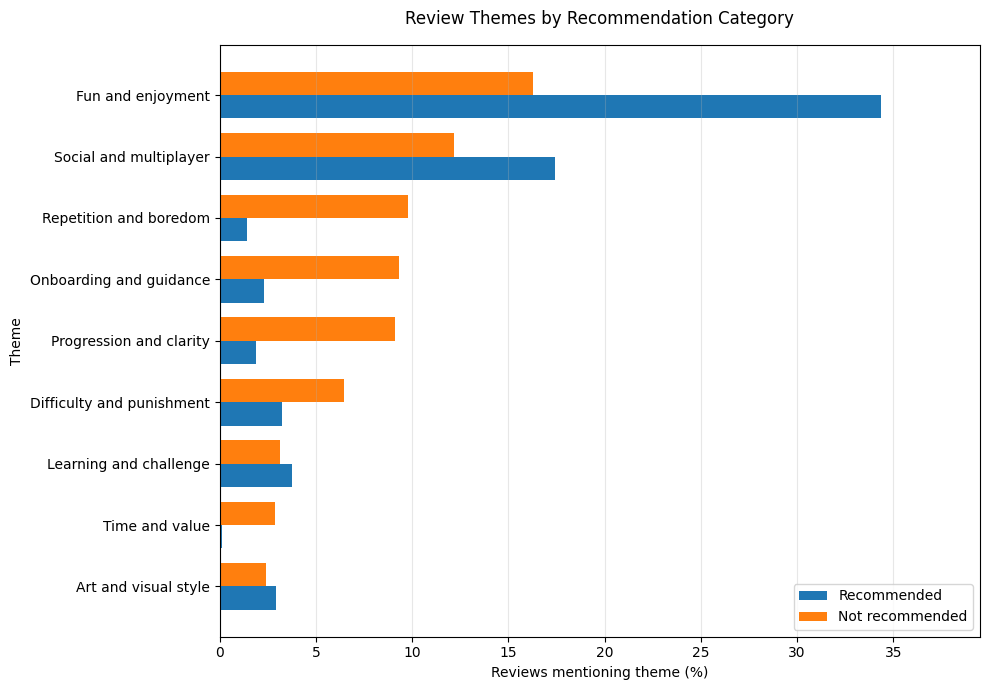

In [33]:
theme_plot_data = (
    theme_summary[
        [
            "recommended_rate",
            "not_recommended_rate",
        ]
    ]
    .sort_values(
        "not_recommended_rate",
        ascending=True,
    )
)

figure, axis = plt.subplots(figsize=(10, 7))

y_positions = range(len(theme_plot_data))
bar_height = 0.38

axis.barh(
    [
        position - bar_height / 2
        for position in y_positions
    ],
    theme_plot_data["recommended_rate"],
    height=bar_height,
    label="Recommended",
)

axis.barh(
    [
        position + bar_height / 2
        for position in y_positions
    ],
    theme_plot_data["not_recommended_rate"],
    height=bar_height,
    label="Not recommended",
)

axis.set_yticks(list(y_positions))
axis.set_yticklabels(theme_plot_data.index)

axis.set_title(
    "Review Themes by Recommendation Category",
    pad=15,
)
axis.set_xlabel("Reviews mentioning theme (%)")
axis.set_ylabel("Theme")
axis.grid(
    axis="x",
    alpha=0.3,
)
axis.legend()

maximum_rate = theme_plot_data.to_numpy().max()

axis.set_xlim(
    0,
    maximum_rate * 1.15,
)

figure.tight_layout()

figure.savefig(
    figures_dir / "10_review_theme_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [34]:
negative_theme_names = [
    "Repetition and boredom",
    "Onboarding and guidance",
    "Progression and clarity",
    "Difficulty and punishment",
    "Time and value",
]

negative_theme_plot = (
    theme_summary.loc[
        negative_theme_names,
        [
            "not_recommended_count",
            "not_recommended_rate",
            "difference_pp",
        ],
    ]
    .sort_values(
        "not_recommended_rate",
        ascending=True,
    )
)

negative_theme_plot.round(2)

,not_recommended_count,not_recommended_rate,difference_pp
theme,,,
Time and value,12,2.87,2.72
Difficulty and punishment,27,6.46,3.21
Progression and clarity,38,9.09,7.19
Onboarding and guidance,39,9.33,7.03
Repetition and boredom,41,9.81,8.37


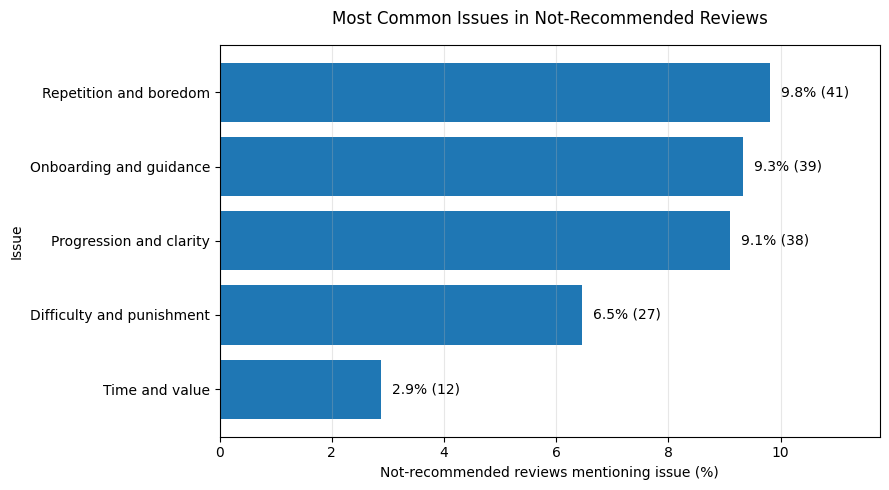

In [35]:
figure, axis = plt.subplots(figsize=(9, 5))

bars = axis.barh(
    negative_theme_plot.index,
    negative_theme_plot["not_recommended_rate"],
)

axis.set_title(
    "Most Common Issues in Not-Recommended Reviews",
    pad=15,
)
axis.set_xlabel("Not-recommended reviews mentioning issue (%)")
axis.set_ylabel("Issue")
axis.grid(
    axis="x",
    alpha=0.3,
)

maximum_rate = (
    negative_theme_plot["not_recommended_rate"].max()
)

axis.set_xlim(
    0,
    maximum_rate * 1.2,
)

for bar, rate, count in zip(
    bars,
    negative_theme_plot["not_recommended_rate"],
    negative_theme_plot["not_recommended_count"],
):
    axis.text(
        bar.get_width() + maximum_rate * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}% ({int(count)})",
        va="center",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "11_negative_review_issues.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [36]:
positive_theme_names = [
    "Fun and enjoyment",
    "Social and multiplayer",
    "Art and visual style",
    "Learning and challenge",
]

positive_theme_plot = (
    theme_summary.loc[
        positive_theme_names,
        [
            "recommended_count",
            "recommended_rate",
            "difference_pp",
        ],
    ]
    .sort_values(
        "recommended_rate",
        ascending=True,
    )
)

positive_theme_plot.round(2)

,recommended_count,recommended_rate,difference_pp
theme,,,
Art and visual style,120,2.93,-0.54
Learning and challenge,153,3.74,-0.63
Social and multiplayer,714,17.44,-5.24
Fun and enjoyment,1406,34.35,-18.08


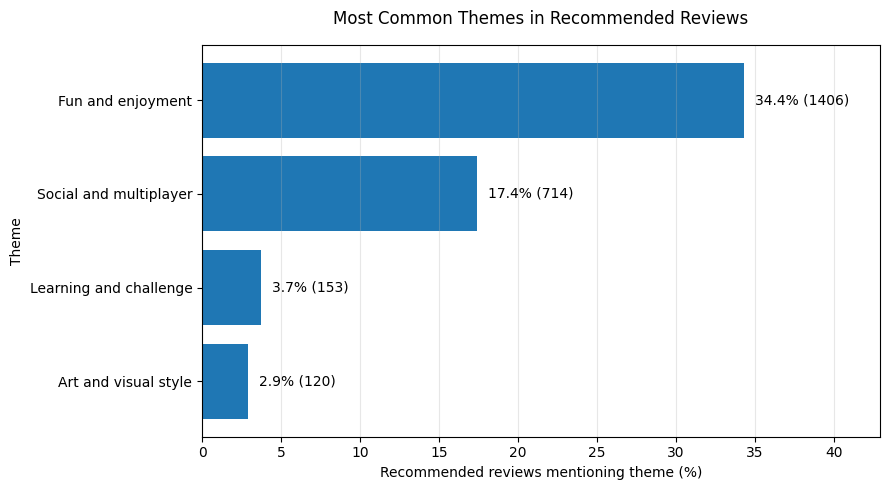

In [37]:
figure, axis = plt.subplots(figsize=(9, 5))

bars = axis.barh(
    positive_theme_plot.index,
    positive_theme_plot["recommended_rate"],
)

axis.set_title(
    "Most Common Themes in Recommended Reviews",
    pad=15,
)
axis.set_xlabel("Recommended reviews mentioning theme (%)")
axis.set_ylabel("Theme")
axis.grid(
    axis="x",
    alpha=0.3,
)

maximum_rate = (
    positive_theme_plot["recommended_rate"].max()
)

axis.set_xlim(
    0,
    maximum_rate * 1.25,
)

for bar, rate, count in zip(
    bars,
    positive_theme_plot["recommended_rate"],
    positive_theme_plot["recommended_count"],
):
    axis.text(
        bar.get_width() + maximum_rate * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}% ({int(count)})",
        va="center",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "12_positive_review_themes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

fun, enjoyment是最重要的正面主题，出现在34.35%的推荐评论中。social, multiplayer experiences也十分突出，占17.44%的正面评价。这表明游戏的乐趣以及与其他玩家互动是其主要优势。
不推荐评论中最常见的问题包括repetition, boredom, onboarding, guidance, progression, clarity。这些主题在约9%至10%的负面评论中出现。
Difficulty, punishment 在负面评论中出现得更频繁，但learning, challenge在两组中的出现频率相似。这表明挑战本身并不总是负面的。难点的呈现方式和解释可能比单纯难度更为重要。
主题分类基于关键词规则，同一条评论可能涉及多个主题。因此，结果反映的是提及每个主题的评论比例，而非互斥的类别。

In [38]:
theme_output_path = (
    project_root
    / "data"
    / "processed"
    / "dst_reviews_with_themes.csv"
)

theme_data.to_csv(
    theme_output_path,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", theme_output_path)
print("Shape:", theme_data.shape)

Saved: /Users/zhouzhou/Desktop/dst-review-analysis/data/processed/dst_reviews_with_themes.csv
Shape: (4511, 12)
